(The cells must be executed sequentially)

In [1]:
from scipy.optimize import curve_fit
from common_functions import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import quad
import copy
from scipy.signal import argrelextrema

# SIMULATE DETERMINISTIC DYNAMICS, STARTING NEAR DFE, UNTIL SYSTEM REACHES ITS LONG-TERM STATE

In [2]:
g = 0.8       # recovery rate; average recovery is 1 / g weeks
b = 2.2       # baseline contact rate
w = 52        # period of forcing, assuming 52 weeks in a year
d = 1 / 52    # immunity loss rate; immunity on average lasts 1 / d weeks
A = 0.35      # strength of forcing
p = 0         # phase of forcing
N = 50000     # total population size

# forcing period measured in the slow time coordinate tau
forcing_period = abs(d * w)

# initialize simulation duration and step size
sim_len = 151 * forcing_period; dt = 0.00005

# initialize population sizes
y0       = 0.01 / d
initials = [1 - y0 * d, y0]

# get trajectory
tau_list, x_list, y_list = sim_SIRS_scaled(sim_len, dt, initials, b, d, g, A, p, w) # function defined in `common_functions.py`

Text(0.5, 0, '$\\tau$')

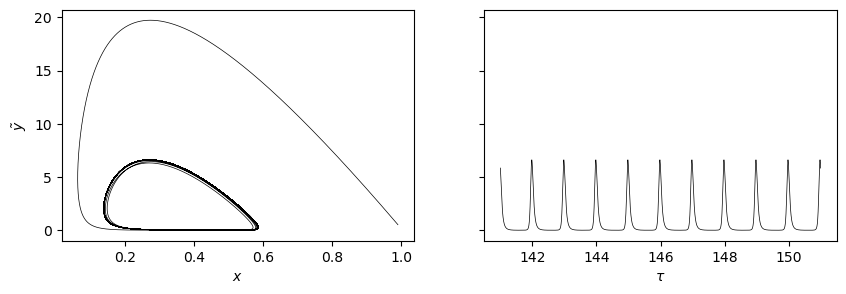

In [3]:
# check what trajectory looks like in (x, \tilde{y})-plane
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 3))
ax[0].plot(x_list, y_list, linewidth=0.5, color='k')
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$\tilde{y}$')

# check what disease prevalence time series looks like for the terminal 10 years
cutoff_idx = get_trailing_periods(sim_len, 10, forcing_period, dt) # function defined in 'common_functions.py'
ax[1].plot(tau_list[cutoff_idx:], y_list[cutoff_idx:], linewidth=0.5, color='k')
ax[1].set_xlabel(r'$\tau$')

(0.0, 1.0)

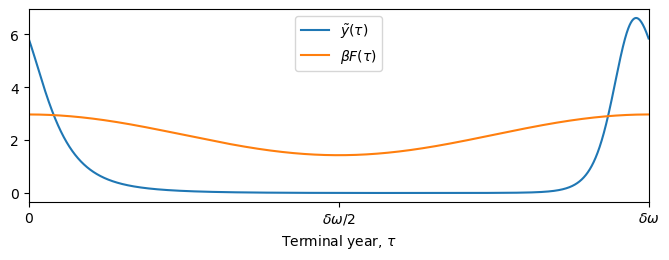

In [4]:
# extract terminal year from data
cutoff_ind = get_trailing_periods(sim_len, 1, forcing_period, dt) # function defined in 'common_functions.py'
x          = x_list[cutoff_ind:]
y          = y_list[cutoff_ind:]
tau        = tau_list[cutoff_ind:]

# normalize time such that it is between 0 and `forcing_period`
tau = list(forcing_period * normalize_data(np.array(tau))) # function defined in 'common_functions.py'

# plot the final period and the varying transmission rate
fig, ax = plt.subplots(1, figsize=(8, 2.5))
ax.plot(tau, y, label=r'$\tilde{y}(\tau)$')
ax.plot(tau, b * F_scaled(np.array(tau), b, d, A, p, w), label=r'$\beta F(\tau)$')
ax.legend(loc="best")
ax.set_xlabel(r'Terminal year, $\tau$')
ax.set_xticks([0, forcing_period/2, forcing_period], ["0", r"$\delta\omega/2$", r"$\delta\omega$"])
ax.set_xlim([0, forcing_period])

# FIT ANALYTICAL EXPRESSION $\tilde{y}=K\exp\{B(\tau)\}$ TO THE INTER-EPIDEMIC TROUGH TO ESTIMATE THE CONSTANTS $K$ AND $x_0$

In [5]:
# only fit to the trough
y_fit   = []
tau_fit = []
max_y   = min(y) + 0.04
for i in range(len(y)):
    if y[i] < max_y:
        y_fit.append(y[i])
        tau_fit.append(tau[i])

print(r"Range of $\tilde{y}$ a we are fitting to: [" + str(min(y_fit)) + ", " + str(max(y_fit)) + "]")

Range of $\tilde{y}$ a we are fitting to: [0.0014436603207997488, 0.04142493929377518]


In [6]:
def a(s): # argument of sinusoidal functions
    return (2 * np.pi * (s / d + p) / w)
def B(s, x0):
    return (b * (A * w * (d * w * np.cos(a(s)) - 2 * np.pi * np.sin(a(s))) / ((d * w)**2 + (2 * np.pi)**2) + 1 / d) * (1 - x0) * np.exp(-s)
             + (b - g) * s / d + A * b * w * np.sin(a(s)) / (2 * np.pi))
def seg_C(tau, ln_K, x0): 
    return np.exp(ln_K) * np.exp(B(tau, x0))

Most likely `curve_fit` will output a bad or mediocre fit if a reasonable initial guess is not provided. An initial guess is obtained by solving the system of equations

$0 = -\ln($ `y_fit[0]` $) + \ln(K) + B($ `tau_fit[0]` $)$,

$0 = -\ln($ `y_fit[-1]` $) + \ln(K) + B($ `tau_fit[-1]` $)$

for $\ln(K)$ and $x_0$.

In [7]:
# find an initial guess for parameters
ln_K_ = sp.symbols('ln(K)', real=True)
x0_   = sp.symbols('x0', real=True, nonnegative=True)

eq1    = sp.Eq(-np.log(y_fit[0]) + ln_K_ + B(tau_fit[0], x0_), 0) 
eq2    = sp.Eq(-np.log(y_fit[-1]) + ln_K_ + B(tau_fit[-1], x0_), 0)
output = sp.solve((eq1, eq2), (ln_K_, x0_))

ln_K_guess = float(output[ln_K_])
x0_guess   = float(output[x0_])
p0         = [ln_K_guess, x0_guess]

print("initial guess: ln(K) = " + str(p0[0]) + ", x0 = " + str(p0[1]))

initial guess: ln(K) = -108.94228784076213, x0 = 0.02873211870464584


curve_fit guess: ln(K) = -108.93933323936433, x0 = 0.028710495877809987


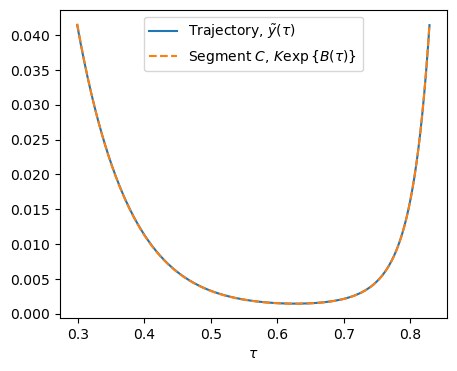

In [8]:
# fit analytical expression to trough 
popt, pcov = curve_fit(seg_C, tau_fit, y_fit, p0=p0, maxfev=100000)

fig, ax = plt.subplots(1, figsize=(5, 4))
ax.plot(tau_fit, y_fit, label=r'Trajectory, $\tilde{y}(\tau)$')
ax.plot(tau_fit, list(seg_C(np.array(tau_fit), *popt)), linestyle='--', label=r'Segment $C$, $K\exp\{B(\tau)\}$')
ax.set_xlabel(r'$\tau$')
ax.legend(loc="best")

ln_K = popt[0]
x0   = popt[1]
print("curve_fit guess: ln(K) = " + str(ln_K) + ", x0 = " + str(x0))

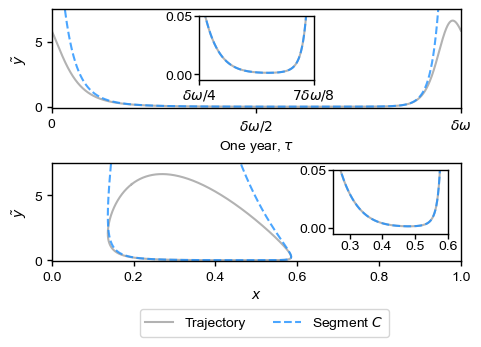

In [9]:
set_rcParams()

# figure dimensions
fig_height = 3    # height (in inches)
fig_width  = 4.7  # width (in inches)

# initialize figure
fig, ax = plt.subplots(2, 1, figsize=(fig_width, fig_height), constrained_layout=True)

y_max = 7.5

# compute segment C
dashed_line = list(seg_C(np.array(tau), *popt))

################################
# plot trajectory and segment C
axins1 = inset_axes(ax[0], width="28%", height="65%", loc="upper center")
for axis in [ax[0], axins1]:
    axis.plot(tau, y, 'k', alpha=0.3, label="Trajectory")
    axis.plot(tau, dashed_line, color='dodgerblue', linestyle='--', alpha=0.8, label="Segment $C$")
    
axins2 = inset_axes(ax[1], width="28%", height="65%", loc="upper right", bbox_to_anchor=(-0.015, 0, 1, 1), bbox_transform=ax[1].transAxes)
for axis in [ax[1], axins2]:
    axis.plot(x, y, 'k', alpha=0.3, label="Trajectory")
    axis.plot(x, dashed_line, color='dodgerblue', linestyle='--', alpha=0.8, label="Segment $C$")

################################
# label axes
ax[0].set_xlabel(r"One year, $\tau$")
ax[0].set_ylabel(r"$\tilde{y}$")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel(r"$\tilde{y}$")

################################
# set axis limits

# top row parent plot
ax[0].set_xlim([0, forcing_period])
ax[0].set_ylim([-0.1, y_max])

# top row inset plot
axins1.set_ylim([-0.005, 0.05])
axins1.set_xlim([forcing_period/4, 7*forcing_period/8])

# bottom row parent plot
ax[1].set_xlim([0, 1])
ax[1].set_ylim([-0.1, y_max])

# bottom row inset plot
axins2.set_xlim([0.25, 0.6])
axins2.set_ylim([-0.005, 0.05])

################################
# set axis ticks
ax[0].set_xticks([0, forcing_period/2, forcing_period], ["0", r"$\delta\omega/2$", r"$\delta\omega$"])
axins1.set_xticks([forcing_period/4, 7*forcing_period/8], [r"$\delta\omega/4$", r"$7\delta\omega/8$"])

################################
# adjust tick label padding for inset plots
axins1.tick_params(axis='both', which='major', pad=1.2)
axins2.tick_params(axis='both', which='major', pad=1.2)

################################
# legend stuff
unique_label_legend(fig) # defined in `common_functions.py`

# save figure
if A == 0.35:
    plt.savefig("plots/lim_cycle_expansion.pdf", bbox_inches="tight", dpi=600)

# EVALUATE ASYMPTOTIC APPROXIMATION OF DISEASE BURNOUT PROBABILITY

In [10]:
x             = lambda s: 1 - (1 - x0) * np.exp(-s)
integral, err = quad(lambda s: (b * F_scaled(s, b, d, A, p, w) * x(s) + g) * np.exp(-B(s, x0)), -np.inf, np.inf)
K             = np.exp(ln_K)
prob          = np.exp(-2 * K * N * (d**2) * (integral**(-1)))

print("Probability of disease elimination at terminal inter-epidemic trough: ~" + str(prob))

Probability of disease elimination at terminal inter-epidemic trough: ~0.8678633874253691


# DRAW COORDINATE GRID OF TRANSFORMED COORDINATES

In [11]:
def create_lines(list1, list2):
    points = 400 # higher number --> smoother curves
    lines  = np.empty((len(list1)+len(list2), 2, points))

    for i in range(len(list1)): # vertical lines
        linspace1 = np.linspace(list1[i], list1[i], points)
        linspace2 = np.linspace(min(list2), max(list2), points)

        lines[i] = (linspace1, linspace2)

    for i in range(len(list2)): # horizontal lines
        linspace1 = np.linspace(min(list1), max(list1), points)
        linspace2 = np.linspace(list2[i], list2[i], points)

        lines[i + len(list1)] = (linspace1, linspace2)
    return lines

def plot_lines(lines, ax):
    for line in lines:
        ax.plot(line[0], line[1], linewidth=0.5, color="k")

In [12]:
f_func    = lambda s: b * F_scaled(s, b, d, A, p, w) * x(s) + g
g_func    = lambda s: np.exp(-B(s, x0))
integrand = lambda s: f_func(s) * g_func(s)

In [13]:
# instead of trying to solve x as a function of T,
# just create two parallel lists, i.e. `xs` and `Ts`,
# to map values of T back to x
n_taus = 50000
taus   = np.linspace(0.4, 0.8, n_taus)
Ts     = []
for i in range(n_taus):
    tau    = taus[i]
    T, err = quad(lambda s: integrand(s) / (N * d**2), tau, np.inf)
    Ts.append(T)

# create lists of evenly spaced numbers for T and zeta
T_range    = np.linspace(min(Ts), max(Ts), 9)
zeta_range = np.linspace(0, 5e-47, 9)  

def take_closest(my_list, my_number):
    # given a list and number, this function
    # will return the index of the element in the list
    # which is closest to the given number
    indx    = 0
    closest = my_list[0]
    for i in range(1, len(my_list)):
        current = my_list[i]
        if abs(current - my_number) < abs(closest - my_number):
            closest = current
            indx    = i
    return indx

# parallel lists for grids
T_grid   = []
tau_grid = []
for i in range(len(T_range)):
    # iterate through the values of evenly spaced
    # values of T, i.e. `T_range`, and find the index
    # of the element in `Ts` which is closest
    closest_indx = take_closest(Ts, T_range[i])

    T_grid.append(Ts[closest_indx]) # record T value
    tau_grid.append(taus[closest_indx]) # record tau value which produces recorded T value

lines     = create_lines(T_grid, zeta_range)
lines_tau = create_lines(tau_grid, zeta_range)

In [14]:
def trans_to_org_coord(lines, lines_tau):
    # transforms (T, zeta) grid to (tau, eta)
    z    = copy.deepcopy(lines) # deep copy so that original grid isn't changed
    tau  = lines_tau[:, 0] # we already have the corresponding values of tau
    zeta = z[:, 1] # get zeta values
    eta  = N * d * zeta * np.exp(B(tau, x0)) / 2 # transforming the zeta coordinates --> eta

    z[:, 0] = tau
    z[:, 1] = eta
    return z

transformed_lines = trans_to_org_coord(lines, lines_tau)

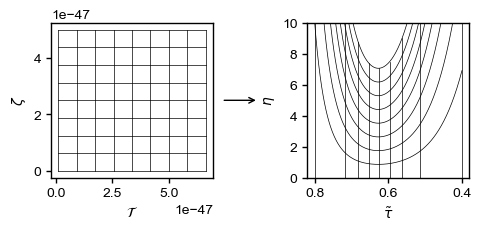

In [15]:
set_rcParams()

# figure dimensions
fig_height = 2.2  # width (in inches)
fig_width  = 4.7  # height (in inches)

# initialize figure
fig, ax = plt.subplots(1, 2, figsize=(fig_width, fig_height), gridspec_kw={'wspace': 0.025})

plot_lines(lines, ax[0])
ax[0].set_xlabel(r'$\mathcal{T}$')
ax[0].set_ylabel(r'$\zeta$')

plot_lines(transformed_lines, ax[1])
ax[1].set_xlabel(r'$\tilde{\tau}$')
ax[1].set_ylabel(r'$\eta$')
ax[1].set_ylim([0,10])
ax[1].invert_xaxis()

# Add arrows between the subplots
arrowprops = dict(arrowstyle="->", linewidth=1, color='k')
arrow1_2   = plt.annotate('', xy=(-0.3, 0.5), xycoords=ax[1].transAxes, xytext=(-0.53, 0.5), textcoords=ax[1].transAxes, arrowprops=arrowprops)

# save figure
if A == 0.35:
    plt.savefig("plots/forcing_trans_coord_grid.pdf", bbox_inches="tight", dpi=600)